In [11]:
#import timeit

import matplotlib.pylab as pylab
import numpy as np
#import numpy.fft as fft
#from   PIL import Image
from   scipy import ndimage, misc, signal
#import scipy.fftpack as fp
#from   scipy.stats import signaltonoise # deprecated
#from   skimage import data, img_as_float
from   skimage.color import rgb2gray
from   skimage.io import imread, imshow, show
#from   skimage.transform import rescale

#%matplotlib inline

In [2]:
IMG = '../../../images'

In [6]:
im = rgb2gray(imread(f'{IMG}/cameraman.jpg')).astype(float)
np.max(im)

0.9921568627450981

In [7]:
im.shape

(256, 256)

In [10]:
blur_box_kernel = np.ones((3, 3)) / 9
edge_laplace_kernel = np.array([[0,  1, 0],
                                [1, -4, 1],
                                [0,  1, 0]])
im_blurred = signal.convolve2d(im, blur_box_kernel)
im_edges = np.clip(signal.convolve2d(im, edge_laplace_kernel), 0, 1)

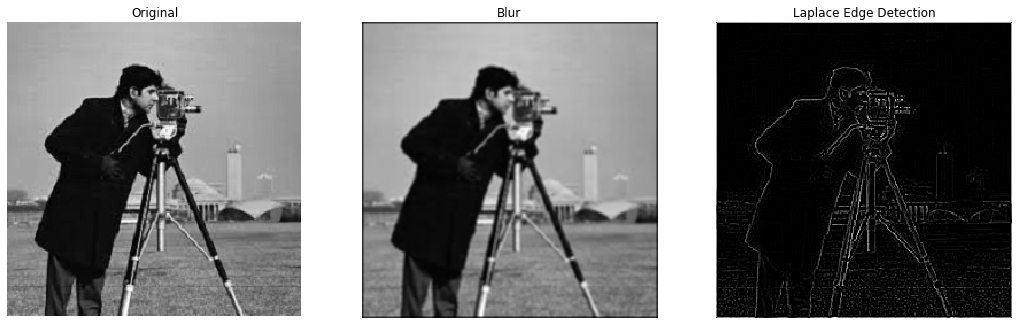

In [12]:
fig, axes = pylab.subplots(
    ncols=3, sharex=True, sharey=True, figsize=(18, 6))
axes[0].imshow(im, cmap=pylab.cm.gray)
axes[0].set_title('Original')
axes[1].imshow(im_blurred, cmap=pylab.cm.gray)
axes[1].set_title('Blur')
axes[2].imshow(im_edges, cmap=pylab.cm.gray)
axes[2].set_title('Laplace Edge Detection')

for ax in axes:
    ax.axis('off')